In [ ]:
import h5py
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt

print(f"PyTorch: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

if DEVICE.type == "cuda":
    torch.backends.cudnn.benchmark = True
    print(f"Using GPU device: {torch.cuda.get_device_name(0)}")
else:
    print("Using CPU")

In [ ]:
PROCESSED_FILE = r"E:\Gam3a\Grad-proj\maestro\datasets\case_processed_v2.h5"

# Preprocessing already aligns labels correctly and downsamples to 20Hz.
# Each window is 5s -> 100 timesteps, so we do NOT downsample further here.
DOWNSAMPLE = 1

def load_data():
    with h5py.File(PROCESSED_FILE, "r") as f:
        x = f["x"][:]
        y = f["y"][:]
        subjects = f["subject_ids"][:]

    x = x.astype(np.float32)
    y = y.astype(np.float32)
    subjects = subjects.astype(np.int32)

    if DOWNSAMPLE > 1:
        x = x[:, ::DOWNSAMPLE, :]

    return x, y, subjects

X, Y, subjects = load_data()
print("Loaded:")
print(f"X: {X.shape} (samples, time_steps, features)")
print(f"Y: {Y.shape} (samples, 2)")
print(f"subjects: {subjects.shape} (samples, 1)")

In [ ]:
def concordance_correlation_coefficient(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    """CCC for 1D arrays."""
    y_true = np.asarray(y_true).reshape(-1)
    y_pred = np.asarray(y_pred).reshape(-1)

    mean_true = np.mean(y_true)
    mean_pred = np.mean(y_pred)
    var_true = np.var(y_true)
    var_pred = np.var(y_pred)

    # Pearson correlation
    corr = np.corrcoef(y_true, y_pred)[0, 1]

    numerator = 2 * corr * np.sqrt(var_true) * np.sqrt(var_pred)
    denominator = var_true + var_pred + (mean_true - mean_pred) ** 2
    return float(numerator / denominator)

In [ ]:
class FeatureGRU(nn.Module):
    """Feature-Sequence GRU: takes a sequence of window statistics."""

    def __init__(
        self,
        input_features: int,
        hidden_size: int = 32,
        num_layers: int = 2,
        dropout: float = 0.2,
    ):
        super().__init__()
        # Input shape: (Batch, Seq_Len, Num_Features) -> (B, 10, 9)
        self.gru = nn.GRU(
            input_size=input_features,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )
        self.head = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(hidden_size, 16),
            nn.ReLU(),
            nn.Linear(16, 2),  # Valence, Arousal
        )

    def forward(self, x):
        # x: (B, T, F)
        out, h = self.gru(x)  # h: (layers, B, H)
        last = h[-1]          # Take the last hidden state
        return self.head(last)

# Build model
# X shape is now (Samples, 10, 9)
INPUT_FEATURES = X.shape[2]
model = FeatureGRU(input_features=INPUT_FEATURES).to(DEVICE)
print(model)

In [ ]:
# Subject-independent split (never mix subjects across splits)
# Test = unseen subjects
TEST_SUBJECTS = [26, 27, 28, 29, 30]
# Validation = unseen during training (but not part of test)
VAL_SUBJECTS = [25]

subj = subjects.flatten()

test_mask = np.isin(subj, TEST_SUBJECTS)
val_mask = np.isin(subj, VAL_SUBJECTS)
train_mask = ~(test_mask | val_mask)

X_train_final = X[train_mask]
y_train_final = Y[train_mask]

X_val = X[val_mask]
y_val = Y[val_mask]

X_test = X[test_mask]
y_test = Y[test_mask]

print(f"Train subjects: {sorted(set(subj[train_mask].tolist()))}")
print(f"Val subjects:   {sorted(set(subj[val_mask].tolist()))}")
print(f"Test subjects:  {sorted(set(subj[test_mask].tolist()))}")

print(f"X_train: {X_train_final.shape} | y_train: {y_train_final.shape}")
print(f"X_val:   {X_val.shape} | y_val:   {y_val.shape}")
print(f"X_test:  {X_test.shape} | y_test:  {y_test.shape}")


RandomForest on window mean+std features:
  val : MSE=1.382464 MAE=0.772389 | CCC(v)=0.1994 CCC(a)=0.2935
  test: MSE=1.290288 MAE=0.718333 | CCC(v)=0.1034 CCC(a)=0.2429
Epoch 01 | lr 1.0e-04 | train 1.21728 | val 0.50903
Epoch 02 | lr 1.0e-04 | train 0.52414 | val 0.50850
Epoch 03 | lr 1.0e-04 | train 0.51689 | val 0.50836
Epoch 04 | lr 1.0e-04 | train 0.51071 | val 0.50810
Epoch 05 | lr 1.0e-04 | train 0.50434 | val 0.50711
Epoch 06 | lr 1.0e-04 | train 0.49792 | val 0.50538
Epoch 07 | lr 1.0e-04 | train 0.49192 | val 0.50217
Epoch 08 | lr 1.0e-04 | train 0.48435 | val 0.49536
Epoch 09 | lr 1.0e-04 | train 0.47782 | val 0.49256
Epoch 10 | lr 1.0e-04 | train 0.47140 | val 0.49023
Epoch 11 | lr 1.0e-04 | train 0.46650 | val 0.48965
Epoch 12 | lr 1.0e-04 | train 0.46164 | val 0.48637
Epoch 13 | lr 1.0e-04 | train 0.45662 | val 0.48372
Epoch 14 | lr 1.0e-04 | train 0.45224 | val 0.48197
Epoch 15 | lr 1.0e-04 | train 0.44818 | val 0.48182
Epoch 16 | lr 1.0e-04 | train 0.44510 | val 0.480

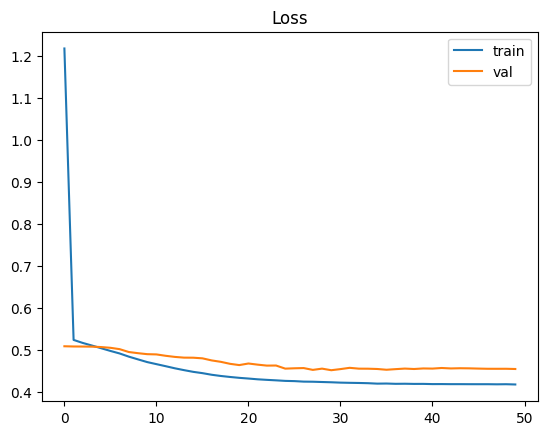

In [14]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.multioutput import MultiOutputRegressor

# ----------------------------
# 0) Sanity checks on labels
# ----------------------------
print("Label stats (train/val/test):")
for name, y in [("train", y_train_final), ("val", y_val), ("test", y_test)]:
    print(
        f"  {name}: min={y.min(axis=0)}, max={y.max(axis=0)}, mean={y.mean(axis=0)}, std={y.std(axis=0)}"
    )

# Mean-prediction baseline (detect the 'predict the dataset mean' trap)
mu = y_train_final.mean(axis=0, keepdims=True)

def report_baseline(split_name, y_true):
    y_pred = np.repeat(mu, repeats=len(y_true), axis=0)
    mse = float(np.mean((y_pred - y_true) ** 2))
    mae = float(np.mean(np.abs(y_pred - y_true)))
    ccc_v = concordance_correlation_coefficient(y_true[:, 0], y_pred[:, 0])
    ccc_a = concordance_correlation_coefficient(y_true[:, 1], y_pred[:, 1])
    print(f"Mean-baseline {split_name}: MSE={mse:.6f} MAE={mae:.6f} | CCC(v)={ccc_v:.4f} CCC(a)={ccc_a:.4f}")

report_baseline("val", y_val)
report_baseline("test", y_test)

# --------------------------------------------
# 1) RandomForest sanity check on features
# --------------------------------------------
# Use simple window summary features (mean + std over time). If this is ~0 CCC too,
# the issue is very likely preprocessing/label alignment rather than the sequence model.
X_train_mean = X_train_final.mean(axis=1)
X_train_std = X_train_final.std(axis=1)
X_val_mean = X_val.mean(axis=1)
X_val_std = X_val.std(axis=1)
X_test_mean = X_test.mean(axis=1)
X_test_std = X_test.std(axis=1)

X_train_rf = np.concatenate([X_train_mean, X_train_std], axis=1)
X_val_rf = np.concatenate([X_val_mean, X_val_std], axis=1)
X_test_rf = np.concatenate([X_test_mean, X_test_std], axis=1)

rf = MultiOutputRegressor(
    RandomForestRegressor(
        n_estimators=500,
        random_state=42,
        n_jobs=-1,
        max_depth=None,
    )
)
rf.fit(X_train_rf, y_train_final)

def report_model(split_name, y_true, y_pred):
    mse = float(np.mean((y_pred - y_true) ** 2))
    mae = float(np.mean(np.abs(y_pred - y_true)))
    ccc_v = concordance_correlation_coefficient(y_true[:, 0], y_pred[:, 0])
    ccc_a = concordance_correlation_coefficient(y_true[:, 1], y_pred[:, 1])
    print(f"{split_name}: MSE={mse:.6f} MAE={mae:.6f} | CCC(v)={ccc_v:.4f} CCC(a)={ccc_a:.4f}")

print("\nRandomForest on window mean+std features:")
report_model("  val ", y_val, rf.predict(X_val_rf))
report_model("  test", y_test, rf.predict(X_test_rf))

# --------------------------------------------
# 2) PyTorch CNN+GRU training (smaller LR + LR scheduler)
# --------------------------------------------

def make_loaders(X_train, y_train, X_val, y_val, batch_size=64):
    pin_mem = DEVICE.type == "cuda"
    train_ds = TensorDataset(torch.from_numpy(X_train), torch.from_numpy(y_train))
    val_ds = TensorDataset(torch.from_numpy(X_val), torch.from_numpy(y_val))
    train_loader = DataLoader(
        train_ds,
        batch_size=batch_size,
        shuffle=True,
        drop_last=False,
        pin_memory=pin_mem,
        num_workers=2,
    )
    val_loader = DataLoader(
        val_ds,
        batch_size=batch_size,
        shuffle=False,
        drop_last=False,
        pin_memory=pin_mem,
        num_workers=2,
    )
    return train_loader, val_loader

BATCH_SIZE = 64  # larger batch to better utilize GPU
EPOCHS = 50
LR = 1e-4  # smaller LR to avoid collapsing to mean
WEIGHT_DECAY = 0.0

train_loader, val_loader = make_loaders(X_train_final, y_train_final, X_val, y_val, batch_size=BATCH_SIZE)

# Huber loss is less sensitive to outliers than MSE
criterion = nn.HuberLoss(delta=1.0)
optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=3,
    min_lr=1e-6,
)

train_losses = []
val_losses = []

for epoch in range(1, EPOCHS + 1):
    model.train()
    total = 0.0
    for xb, yb in train_loader:
        xb = xb.to(DEVICE)
        yb = yb.to(DEVICE)

        optimizer.zero_grad(set_to_none=True)
        pred = model(xb)
        loss = criterion(pred, yb)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        total += loss.item() * xb.size(0)

    train_loss = total / len(train_loader.dataset)

    model.eval()
    total = 0.0
    with torch.no_grad():
        for xb, yb in val_loader:
            xb = xb.to(DEVICE)
            yb = yb.to(DEVICE)
            pred = model(xb)
            loss = criterion(pred, yb)
            total += loss.item() * xb.size(0)

    val_loss = total / len(val_loader.dataset)
    scheduler.step(val_loss)

    lr_now = optimizer.param_groups[0]["lr"]
    train_losses.append(train_loss)
    val_losses.append(val_loss)

    print(f"Epoch {epoch:02d} | lr {lr_now:.1e} | train {train_loss:.5f} | val {val_loss:.5f}")

plt.plot(train_losses, label="train")
plt.plot(val_losses, label="val")
plt.title("Loss")
plt.legend()
plt.show()

## 5. Evaluation

Test MSE: 1.232090 | Test MAE: 0.637251
CCC Valence: 0.1034
CCC Arousal: 0.2230


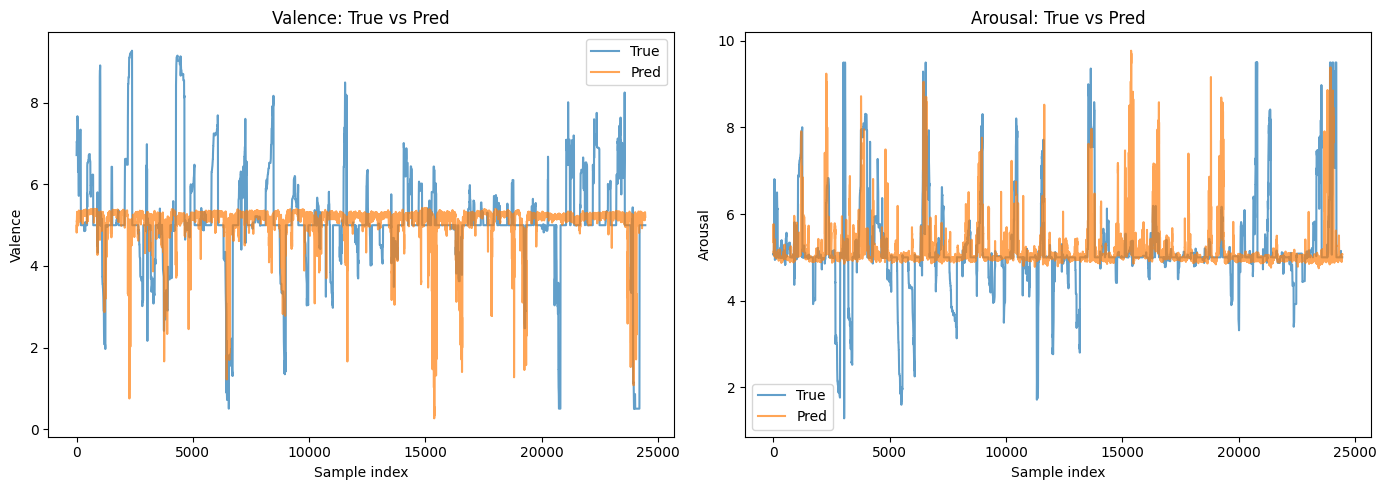

Saved model weights to E:\Gam3a\Grad-proj\maestro\feature_gru_case.pt


In [16]:
# Test evaluation
model.eval()
X_test_t = torch.from_numpy(X_test).to(DEVICE)
y_test_np = y_test

with torch.no_grad():
    y_pred = model(X_test_t).cpu().numpy()

test_mse = float(np.mean((y_pred - y_test_np) ** 2))
test_mae = float(np.mean(np.abs(y_pred - y_test_np)))
print(f"Test MSE: {test_mse:.6f} | Test MAE: {test_mae:.6f}")

ccc_valence = concordance_correlation_coefficient(y_test_np[:, 0], y_pred[:, 0])
ccc_arousal = concordance_correlation_coefficient(y_test_np[:, 1], y_pred[:, 1])
print(f"CCC Valence: {ccc_valence:.4f}")
print(f"CCC Arousal: {ccc_arousal:.4f}")

# Time index for plotting
t = np.arange(len(y_test_np))

plt.figure(figsize=(14, 5))

# Valence: True vs Pred (different colors)
plt.subplot(1, 2, 1)
plt.plot(t, y_test_np[:, 0], label="True", color="tab:blue", alpha=0.7)
plt.plot(t, y_pred[:, 0], label="Pred", color="tab:orange", alpha=0.7)
plt.title("Valence: True vs Pred")
plt.xlabel("Sample index")
plt.ylabel("Valence")
plt.legend()

# Arousal: True vs Pred (different colors)
plt.subplot(1, 2, 2)
plt.plot(t, y_test_np[:, 1], label="True", color="tab:blue", alpha=0.7)
plt.plot(t, y_pred[:, 1], label="Pred", color="tab:orange", alpha=0.7)
plt.title("Arousal: True vs Pred")
plt.xlabel("Sample index")
plt.ylabel("Arousal")
plt.legend()

plt.tight_layout()
plt.show()

# Save model weights
MODEL_PATH = r"E:\Gam3a\Grad-proj\maestro\feature_gru_case.pt"
torch.save(model.state_dict(), MODEL_PATH)
print(f"Saved model weights to {MODEL_PATH}")